# SaltySeq EDA Feature Engineering V2 (Decision Notebook)
## Mục đích
Notebook này chỉ giữ các phần có giá trị ra quyết định ở trạng thái dữ liệu mới nhất:
- Data integrity và readiness cho modeling
- Phân phối target `is_stress_event` sau threshold calibration
- Pattern theo năm/location để hỗ trợ quyết định huấn luyện và validation

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

sns.set_theme(style="whitegrid", context="notebook")

THRESHOLD_APPROVED = -1.315

def find_project_root() -> Path:
    here = Path.cwd().resolve()
    for candidate in [here, *here.parents]:
        if (candidate / "data" / "merged_final.csv").exists():
            return candidate
    raise FileNotFoundError("Cannot locate project root containing data/merged_final.csv")

PROJECT_ROOT = find_project_root()
DATA_PATH = PROJECT_ROOT / "data" / "merged_final.csv"
df = pd.read_csv(DATA_PATH, parse_dates=["date"]).sort_values(["location_id", "date"]).reset_index(drop=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Data path: {DATA_PATH}")
print(f"Shape: {df.shape}")

Project root: D:\SinhVien\UIT_HocChinhKhoa\HK2 2025 - 2026\CS313\DoAN\poc_saltyseq
Data path: D:\SinhVien\UIT_HocChinhKhoa\HK2 2025 - 2026\CS313\DoAN\poc_saltyseq\data\merged_final.csv
Shape: (14610, 61)


## 1) Data Integrity & Readiness Snapshot

In [3]:
total_cells = df.shape[0] * df.shape[1]
completeness = (1 - df.isna().sum().sum() / total_cells) * 100
key_unique = not df.duplicated(["location_id", "date"]).any()

kpi = pd.DataFrame(
    [
        ["Rows", len(df)],
        ["Columns", df.shape[1]],
        ["Date start", df["date"].min().date().isoformat()],
        ["Date end", df["date"].max().date().isoformat()],
        ["Locations", df["location_id"].nunique()],
        ["Panel key unique", key_unique],
        ["Completeness (%)", round(completeness, 4)],
        ["Approved threshold", THRESHOLD_APPROVED],
        ["Stress positive count", int(df["is_stress_event"].sum())],
        ["Stress positive rate (%)", round(df["is_stress_event"].mean() * 100, 4)],
    ],
    columns=["Metric", "Value"],
)
display(kpi)

coverage = (
    df.groupby("location_id", as_index=False)
    .agg(
        rows=("date", "size"),
        start=("date", "min"),
        end=("date", "max"),
        stress_rate=("is_stress_event", "mean"),
    )
    .sort_values("location_id")
)
coverage["stress_rate"] = (coverage["stress_rate"] * 100).round(2)
display(coverage)

,Metric,Value
0,Rows,14610
1,Columns,61
2,Date start,2015-01-01
3,Date end,2022-12-31
4,Locations,5
5,Panel key unique,True
6,Completeness (%),99.5989
7,Approved threshold,-1.315
8,Stress positive count,1461
9,Stress positive rate (%),10.0


,location_id,rows,start,end,stress_rate
0,BT_BaTri,2922,2015-01-01,2022-12-31,9.62
1,BT_BinhDai,2922,2015-01-01,2022-12-31,9.38
2,BT_ChauThanh,2922,2015-01-01,2022-12-31,9.96
3,BT_GiongTrom,2922,2015-01-01,2022-12-31,9.65
4,BT_ThanhPhu,2922,2015-01-01,2022-12-31,11.40


## 2) Target Distribution & Threshold Context

In [4]:
dist = (
    df["is_stress_event"]
    .value_counts()
    .sort_index()
    .rename_axis("is_stress_event")
    .reset_index(name="count")
)
dist["ratio_pct"] = (dist["count"] / len(df) * 100).round(2)
display(dist)

z = df["ndvi_zscore"].dropna()
scenario = pd.DataFrame(
    [
        ["Severe", -2.000, round((z <= -2.000).mean() * 100, 2)],
        [
            "Moderate (approved)",
            THRESHOLD_APPROVED,
            round((z <= THRESHOLD_APPROVED).mean() * 100, 2),
        ],
        ["Mild", float(np.percentile(z, 15)), round((z <= np.percentile(z, 15)).mean() * 100, 2)],
    ],
    columns=["Scenario", "Threshold", "Positive rate (%)"],
)
display(scenario)

,is_stress_event,count,ratio_pct
0,0,13149,90.0
1,1,1461,10.0


,Scenario,Threshold,Positive rate (%)
0,Severe,-2.000000,4.18
1,Moderate (approved),-1.315000,10.00
2,Mild,-1.006125,15.00


## 3) Visual Diagnostics (What the data is saying)

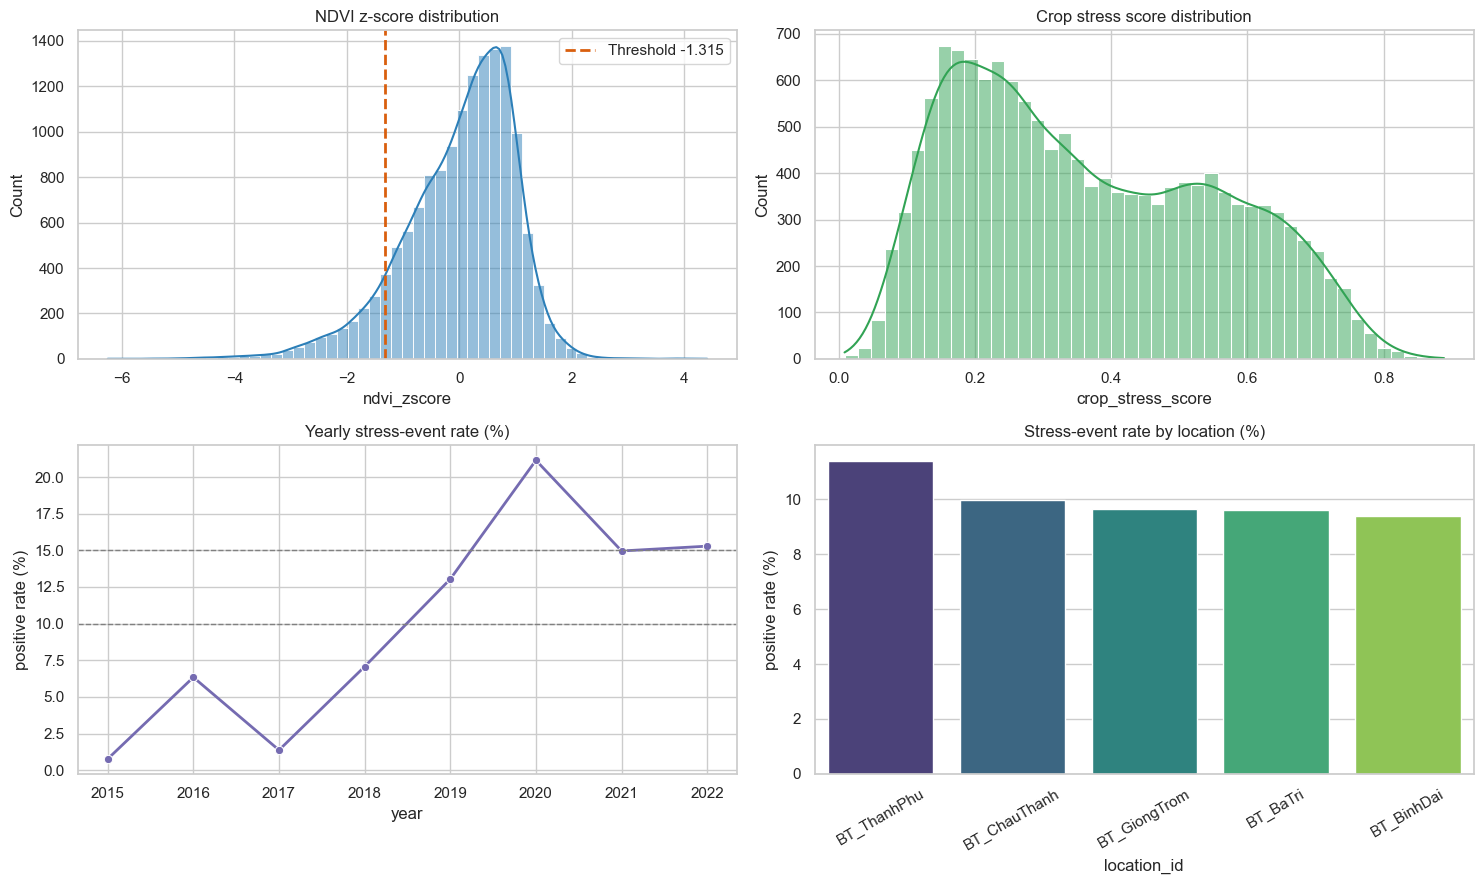

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(15, 9))

sns.histplot(df["ndvi_zscore"].dropna(), bins=55, kde=True, color="#2C7FB8", ax=axes[0, 0])
axes[0, 0].axvline(
    THRESHOLD_APPROVED, color="#D95F0E", linestyle="--", linewidth=2,
    label=f"Threshold {THRESHOLD_APPROVED}",
)
axes[0, 0].set_title("NDVI z-score distribution")
axes[0, 0].set_xlabel("ndvi_zscore")
axes[0, 0].legend()

sns.histplot(df["crop_stress_score"].dropna(), bins=45, kde=True, color="#31A354", ax=axes[0, 1])
axes[0, 1].set_title("Crop stress score distribution")
axes[0, 1].set_xlabel("crop_stress_score")

year_rate = (
    df.assign(year=df["date"].dt.year)
    .groupby("year", as_index=False)["is_stress_event"]
    .mean()
    .assign(rate_pct=lambda d: d["is_stress_event"] * 100)
)
sns.lineplot(data=year_rate, x="year", y="rate_pct", marker="o", linewidth=2, color="#756BB1", ax=axes[1, 0])
axes[1, 0].axhline(10, color="gray", linestyle="--", linewidth=1)
axes[1, 0].axhline(15, color="gray", linestyle="--", linewidth=1)
axes[1, 0].set_title("Yearly stress-event rate (%)")
axes[1, 0].set_ylabel("positive rate (%)")

loc_rate = (
    df.groupby("location_id", as_index=False)["is_stress_event"]
    .mean()
    .assign(rate_pct=lambda d: d["is_stress_event"] * 100)
    .sort_values("rate_pct", ascending=False)
)
sns.barplot(
    data=loc_rate, x="location_id", y="rate_pct", hue="location_id",
    palette="viridis", dodge=False, legend=False, ax=axes[1, 1],
)
axes[1, 1].set_title("Stress-event rate by location (%)")
axes[1, 1].set_ylabel("positive rate (%)")
axes[1, 1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

## 4) Decision Readiness Checklist

In [6]:
checks = pd.DataFrame(
    [
        ["Panel key uniqueness", key_unique, "Required for leakage-safe panel modeling"],
        [
            "Temporal coverage 2015-2022",
            df["date"].min().date().isoformat() == "2015-01-01"
            and df["date"].max().date().isoformat() == "2022-12-31",
            "Matches configured horizon",
        ],
        [
            "Target balance in policy range",
            10 <= df["is_stress_event"].mean() * 100 <= 15,
            "Approved policy: 10%-15%",
        ],
        ["Completeness >= 99%", completeness >= 99, "Preprocessing quality gate"],
    ],
    columns=["Check", "Pass", "Comment"],
)
display(checks)

if checks["Pass"].all():
    print("READY: Dataset dat dieu kien de chuyen sang modeling/validation theo time-series protocol.")
else:
    print("NOT READY: Can xu ly cac check chua dat truoc khi modeling.")

,Check,Pass,Comment
0,Panel key uniqueness,True,Required for leakage-safe panel modeling
1,Temporal coverage 2015-2022,True,Matches configured horizon
2,Target balance in policy range,True,Approved policy: 10%-15%
3,Completeness >= 99%,True,Preprocessing quality gate


READY: Dataset dat dieu kien de chuyen sang modeling/validation theo time-series protocol.
